In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("nav_history_clean.csv")
print("Columns:")
print(nav.columns.tolist())
print("\nFirst 5 Rows:")
print(nav.head())

Columns:
['amfi_code', 'date', 'nav']

First 5 Rows:
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [2]:

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print(nav.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [3]:


def calculate_var_cvar(group):
    returns = group['daily_return'].dropna()

    var_95 = np.percentile(returns, 5)

    cvar = returns[returns <= var_95].mean()

    return pd.Series({
        'VaR_95': var_95,
        'CVaR': cvar
    })



var_cvar_report = nav.groupby('amfi_code').apply(calculate_var_cvar).reset_index()

print(var_cvar_report.head())

   amfi_code    VaR_95      CVaR
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


/tmp/ipykernel_16122/332693265.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  var_cvar_report = nav.groupby('amfi_code').apply(calculate_var_cvar).reset_index()


In [4]:
var_cvar_report.to_csv("var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


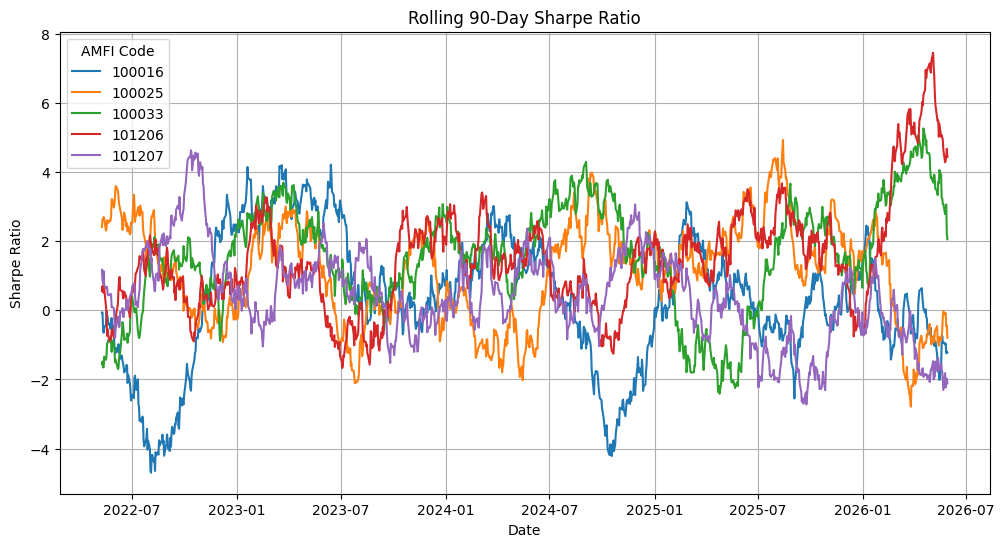

In [5]:
import matplotlib.pyplot as plt

top_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top_funds:
    fund_data = nav[nav['amfi_code'] == fund].copy()
    rolling_sharpe = (
        fund_data['daily_return'].rolling(90).mean() /
        fund_data['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [6]:
# Investor Transactions Data Load
investor = pd.read_csv("investor_transactions_clean.csv")
print(investor.columns.tolist())

print("\nFirst 5 Rows:")
print(investor.head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 Rows:
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-4

In [7]:

investor['transaction_date'] = pd.to_datetime(investor['transaction_date'])
first_txn = investor.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year
investor = investor.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)
cohort_analysis = investor.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum')
).reset_index()

print(cohort_analysis)

   cohort_year  avg_sip_amount  total_invested
0         2024   107422.541832      3491125187
1         2025   109158.577061        30455243


In [8]:
cohort_analysis.to_csv("cohort_analysis.csv", index=False)

print("cohort_analysis.csv saved successfully!")

cohort_analysis.csv saved successfully!


In [9]:

sip = investor[investor['transaction_type'].str.upper() == 'SIP'].copy()
sip = sip.sort_values(['investor_id', 'transaction_date'])
sip['gap_days'] = sip.groupby('investor_id')['transaction_date'].diff().dt.days

sip_summary = sip.groupby('investor_id').agg(
    sip_count=('transaction_date', 'count'),
    avg_gap_days=('gap_days', 'mean')
).reset_index()

sip_summary = sip_summary[sip_summary['sip_count'] >= 6]
sip_summary['risk_flag'] = np.where(
    sip_summary['avg_gap_days'] > 35,
    'At-Risk',
    'Healthy'
)

print(sip_summary.head())
print("\nTotal Investors:", len(sip_summary))

   investor_id  sip_count  avg_gap_days risk_flag
3    INV000004          6     85.400000   At-Risk
7    INV000008          6     70.400000   At-Risk
9    INV000010          6     64.800000   At-Risk
10   INV000011          7     40.166667   At-Risk
11   INV000012          8     57.000000   At-Risk

Total Investors: 1362


In [10]:
sip_summary.to_csv("sip_continuity.csv", index=False)

print("sip_continuity.csv saved successfully!")

sip_continuity.csv saved successfully!


In [11]:

scheme = pd.read_csv("scheme_performance_clean.csv")

print(scheme.columns.tolist())

print("\nFirst 5 Rows:")
print(scheme.head())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

First 5 Rows:
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.

In [12]:

recommendations = (
    scheme
    .sort_values(
        ['risk_grade', 'sharpe_ratio', 'return_3yr_pct'],
        ascending=[True, False, False]
    )
    .groupby('risk_grade')
    .head(3)
)

print(recommendations[
    ['risk_grade',
     'scheme_name',
     'fund_house',
     'return_3yr_pct',
     'sharpe_ratio']
])

         risk_grade                                        scheme_name  \
21             High      Kotak Emerging Equity Fund - Regular - Growth   
12             High           ICICI Pru Midcap Fund - Regular - Growth   
38             High                 DSP Midcap Fund - Regular - Growth   
14              Low           ICICI Pru Liquid Fund - Regular - Growth   
23              Low               Kotak Liquid Fund - Regular - Growth   
30              Low                ABSL Liquid Fund - Regular - Growth   
5          Moderate          HDFC Top 100 Fund - Regular Plan - Growth   
34         Moderate      Mirae Asset Large Cap Fund - Regular - Growth   
11         Moderate          ICICI Pru Bluechip Fund - Direct - Growth   
22  Moderately High             Kotak Flexicap Fund - Regular - Growth   
13  Moderately High  ICICI Pru Value Discovery Fund - Regular - Growth   
33  Moderately High              UTI Flexi Cap Fund - Regular - Growth   
2         Very High         SBI Small 

In [13]:
recommendations.to_csv("fund_recommendations.csv", index=False)

print("fund_recommendations.csv saved successfully!")

fund_recommendations.csv saved successfully!


In [14]:
sector = pd.read_csv("09_portfolio_holdings.csv")

print(sector.columns.tolist())
print(sector.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [15]:
hhi = sector.groupby('amfi_code').apply(
    lambda x: (x['weight_pct'] ** 2).sum()
).reset_index(name='HHI')

print(hhi.head())

   amfi_code        HHI
0     100016  1395.3386
1     100033  1475.9226
2     101206  1293.3173
3     101207  2007.0043
4     102885  1747.0902


/tmp/ipykernel_16122/2138549304.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi = sector.groupby('amfi_code').apply(


In [16]:
hhi.to_csv("sector_hhi.csv", index=False)

print("sector_hhi.csv saved successfully!")

sector_hhi.csv saved successfully!


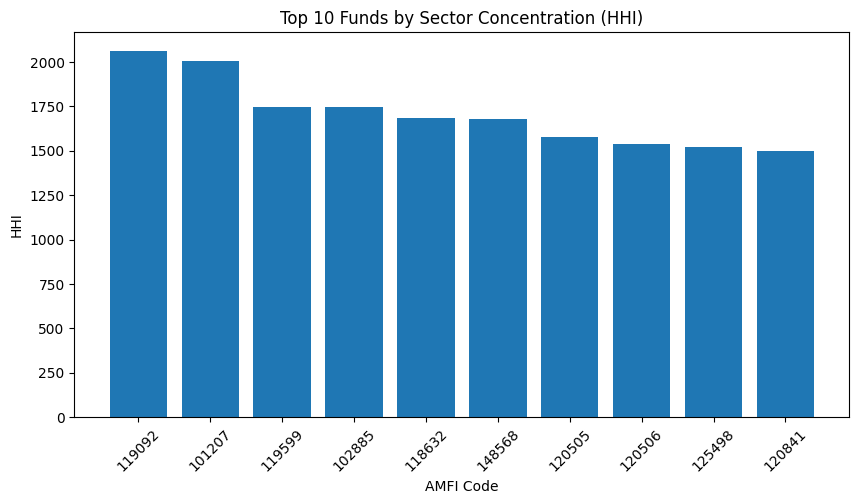

In [17]:
import matplotlib.pyplot as plt

top10 = hhi.sort_values("HHI", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["amfi_code"].astype(str), top10["HHI"])

plt.title("Top 10 Funds by Sector Concentration (HHI)")
plt.xlabel("AMFI Code")
plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.savefig("sector_hhi_chart.png")
plt.show()

In [18]:
insights = [
    "1. Very High risk funds delivered the highest 3-year returns, led by SBI Small Cap Fund.",
    "2. 1362 investors were identified as At-Risk due to irregular SIP continuity patterns.",
    "3. Low-risk liquid funds showed the strongest Sharpe Ratios among conservative options.",
    "4. Sector concentration varied significantly, with some funds exhibiting high HHI values indicating lower diversification.",
    "5. Investors entering in 2025 showed slightly higher average investment amounts compared to 2024 cohorts."
]

for insight in insights:
    print(insight)

1. Very High risk funds delivered the highest 3-year returns, led by SBI Small Cap Fund.
2. 1362 investors were identified as At-Risk due to irregular SIP continuity patterns.
3. Low-risk liquid funds showed the strongest Sharpe Ratios among conservative options.
4. Sector concentration varied significantly, with some funds exhibiting high HHI values indicating lower diversification.
5. Investors entering in 2025 showed slightly higher average investment amounts compared to 2024 cohorts.
